## Tasks:
```
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
5.Apply Lasso and Ridge methods on the model.

```

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Loading data into our enviroment
dataset = pd.read_csv("ToyotaCorolla - MLR.csv")

# Working on a copy set
df = dataset.copy()



print("\n<------It will give the information about our data------->\n")
print(df.info())

print("\n<------It will describe all about our dataset------->\n")
print(df.describe(include="all"))

print("\n<------It will give the number of null values  in each columns------->\n")
print(df.isnull().sum())

print("\n<----------Correlation between the variables------------>\n")
print(df.corr(numeric_only=True))


<------It will give the information about our data------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None

<------It will describe all about our dataset------->

               Price    Age_08_04             KM Fuel_Type           HP  \
count    1436.000000  1436.000000    1436.000000      1436  1436.000000   
unique           NaN          NaN            NaN         3   

## Exploratory Data Analysis(EDA)

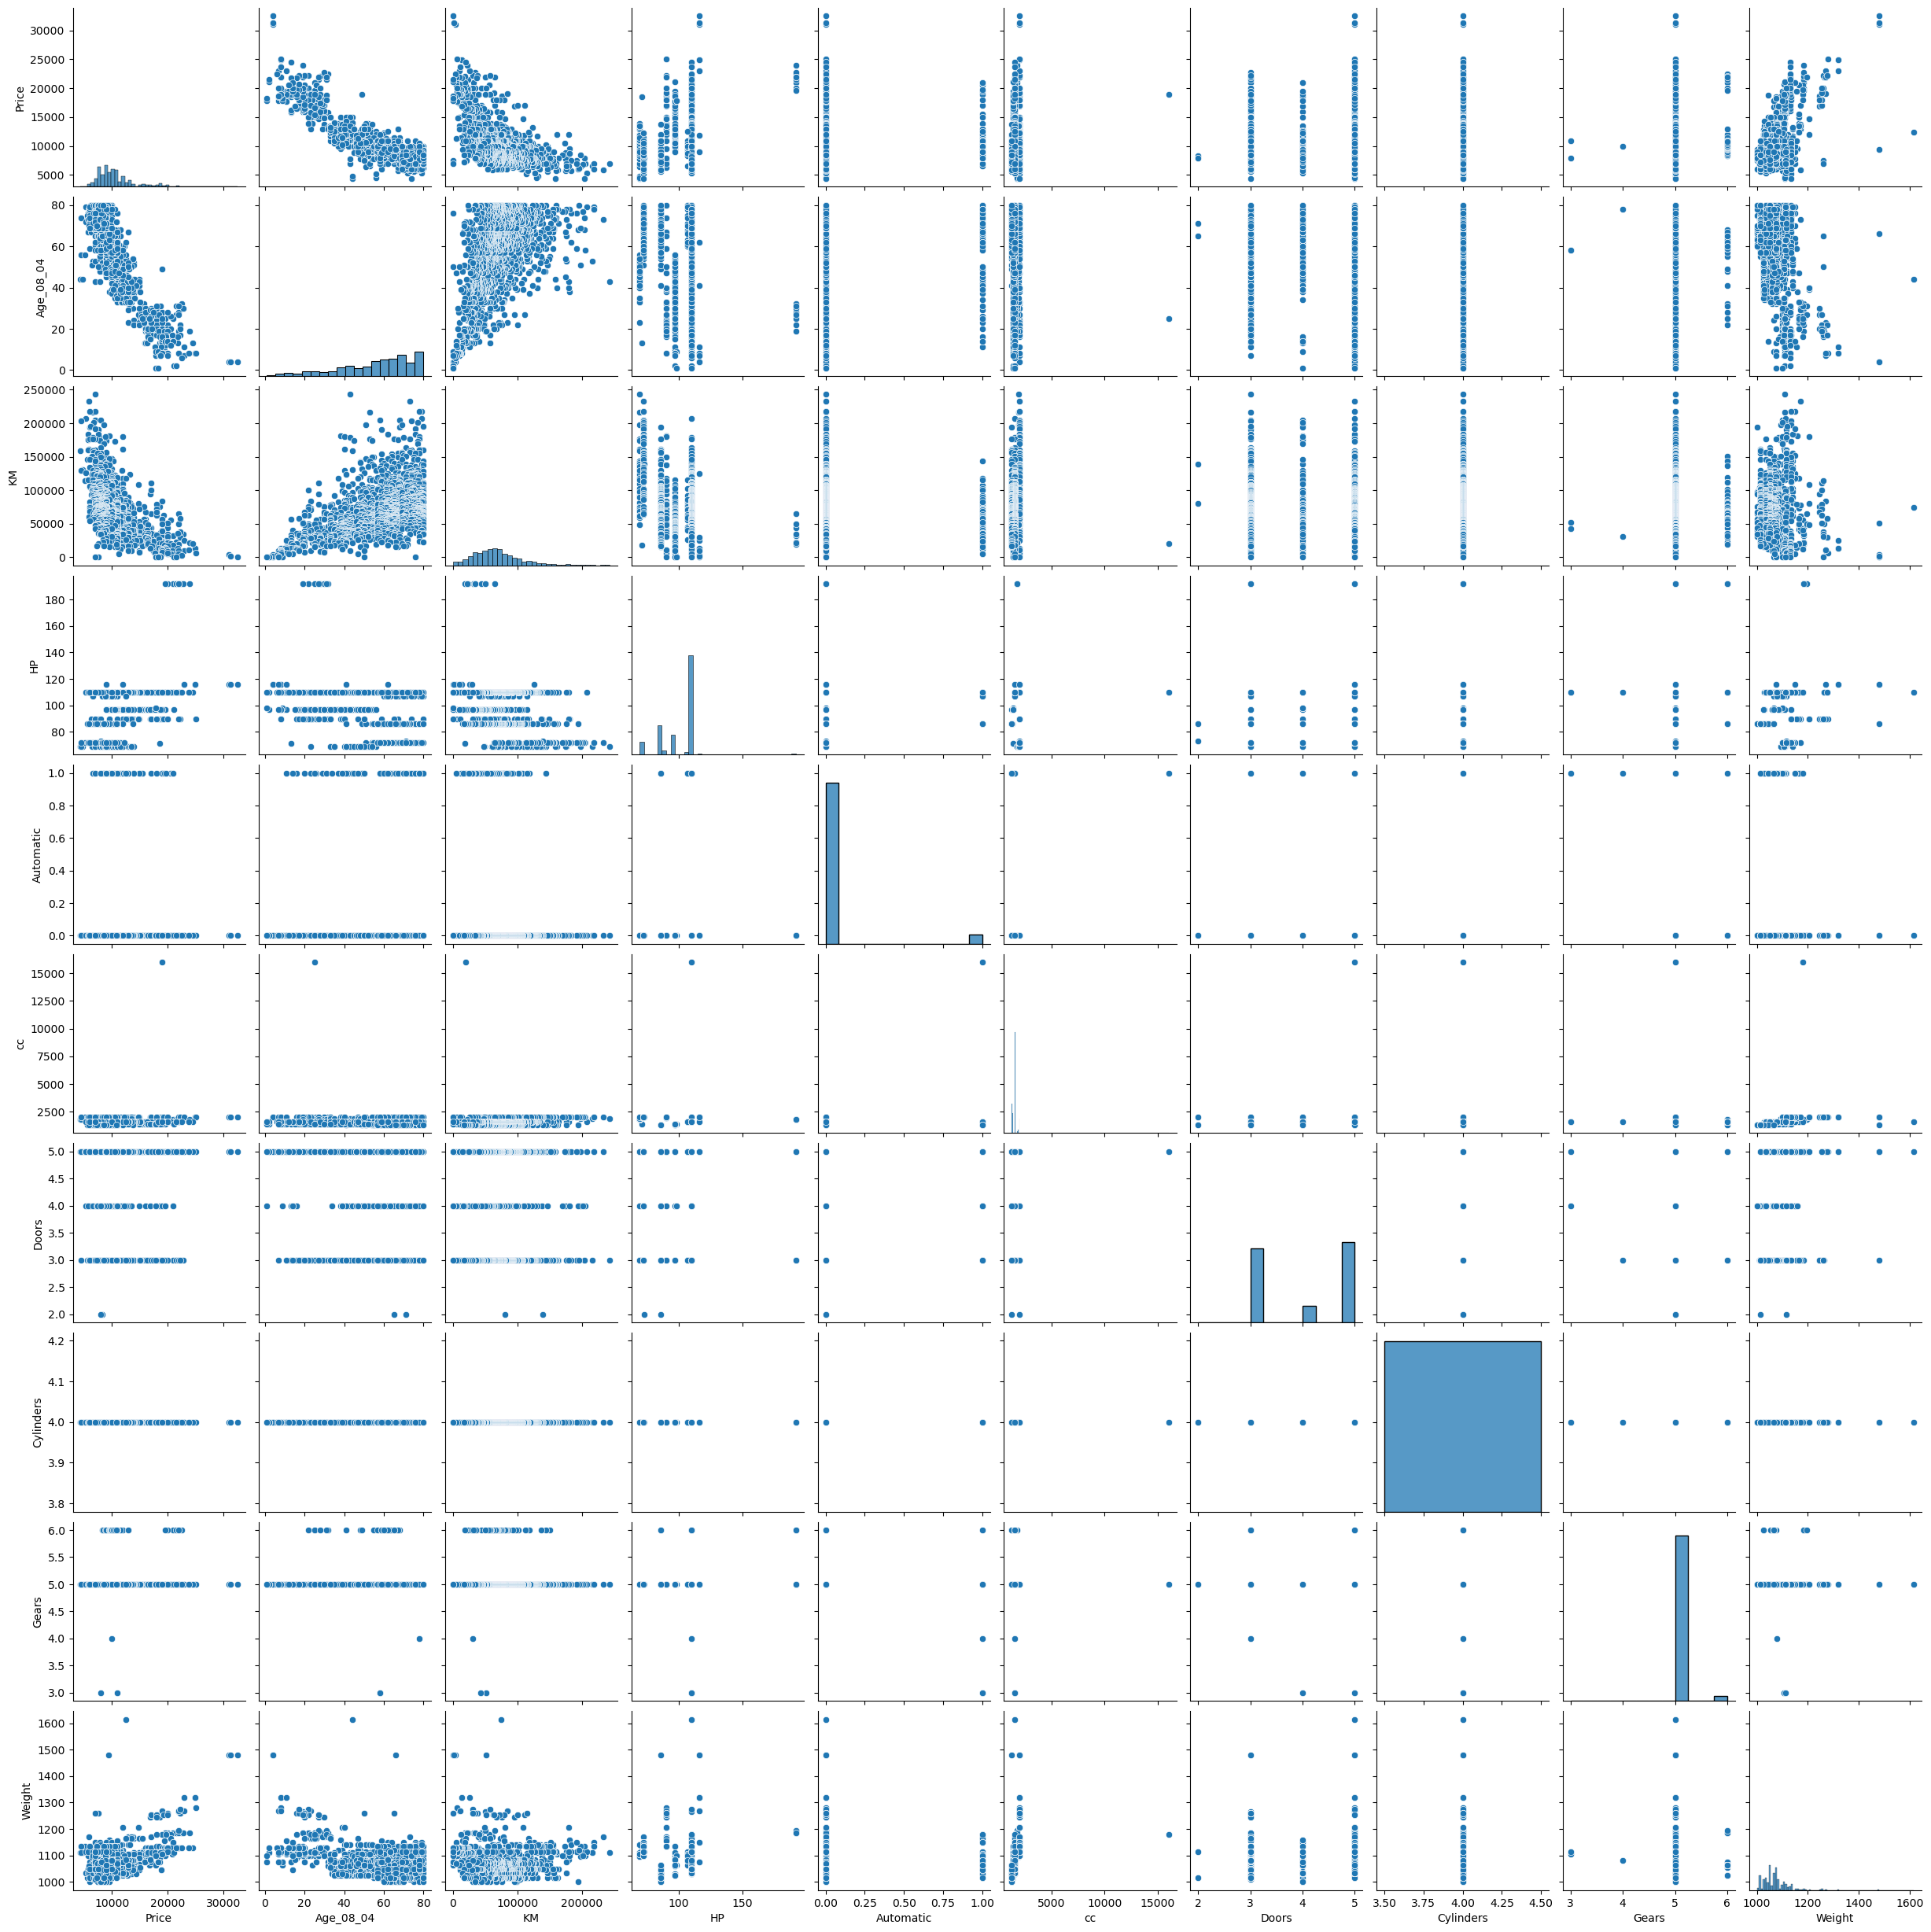

In [2]:
# Visualization plot for all the numerical variables and their relation between them
sns.pairplot(df)
plt.show()

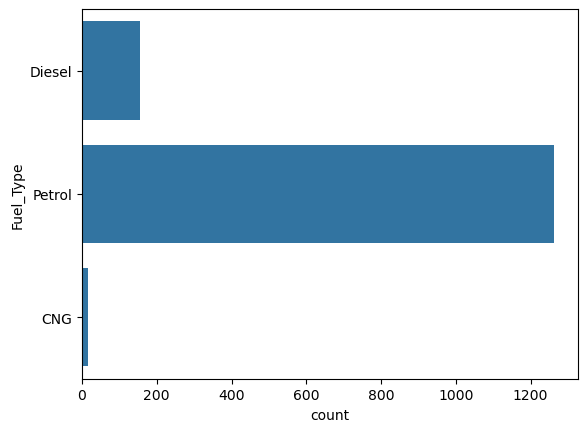

In [3]:
sns.countplot(df['Fuel_Type'])
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("Price",axis=1)
y = df["Price"]

# Train -test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,random_state=42)


In [5]:
# Scaling the variables using appropriate scaling methods
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numerical_cols = X.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numerical_cols),("cate",OneHotEncoder(),categorical_cols)])


In [6]:
#Model building 3 different types of Linear model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


# Model-1: LinearRegression
model_1 = Pipeline(steps=[("preprocessor",preprocessor),("regressor",LinearRegression())])
model_1.fit(X_train,y_train)

#Model-2 : LinearRegression with only numerical features
model_2 = Pipeline(steps=[("scaler",StandardScaler()),("regressor",LinearRegression())])
model_2.fit(X_train[numerical_cols],y_train)

#Model-3 : LinearRegression with interactions (poly features)
poly = PolynomialFeatures(degree=2, include_bias=False)
model_3 = Pipeline(steps=[("preprocessor",preprocessor),("poly",poly),("regressor",LinearRegression())])
model_3.fit(X_train,y_train)


,steps,"[('preprocessor', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cate', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_models(model,Xtest,ytest,name="Model"):
    y_pred = model.predict(Xtest)
    mse = mean_squared_error(y_pred,ytest)
    mae = mean_absolute_error(y_pred,ytest)
    rmse = np.sqrt(mse)
    r2 =r2_score(y_pred,y_test)
    print(name)
    print(f"MSE: {mse}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R² Score: {r2}")
    
print("\n<----------Evaluation metrics for model_1----------->\n")
evaluate_models(model_1,X_test,y_test,"Model_1: Linear Model")
print("\n<----------Evaluation metrics for model-2---------->\n")
evaluate_models(model_2,X_test[numerical_cols],y_test,"Model_2: Linear Model only_numerical columns")
print("\n<----------Evaluation metrics for model_3----------->\n")
evaluate_models(model_3,X_test,y_test,"Model_3: Linear Model usding polynomial features")


<----------Evaluation metrics for model_1----------->

Model_1: Linear Model
MSE: 2203043.8231437043
MAE: 990.8872739193968
RMSE: 1484.265415329652
R² Score: 0.8155468538431174

<----------Evaluation metrics for model-2---------->

Model_2: Linear Model only_numerical columns
MSE: 1970126.6288130332
MAE: 997.002405725814
RMSE: 1403.6119936838077
R² Score: 0.8311416575755124

<----------Evaluation metrics for model_3----------->

Model_3: Linear Model usding polynomial features
MSE: 3198379.343319576
MAE: 908.7901871177513
RMSE: 1788.4013373176547
R² Score: 0.7884649862019469


In [10]:
from sklearn.linear_model import Lasso,Ridge

#using Lasso and Ridge Models
model_lasso = Pipeline(steps=[("preprocessor",preprocessor),("regressor",Lasso())])
model_lasso.fit(X_train,y_train)

model_ridge =Pipeline(steps=[("prerocessor",preprocessor),("regressor",Ridge())])
model_ridge.fit(X_train,y_train)

,steps,"[('prerocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cate', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Evaluation metrics for the Lasso and the ridge
print("\n<----------Evaluation metrics for lasso----------->\n")
evaluate_models(model_lasso,X_test,y_test,name="Model_Lasso")
print("\n<----------Evaluation metrics for ridge----------->\n")
evaluate_models(model_ridge,X_test,y_test,name="Model_Ridge")


<----------Evaluation metrics for lasso----------->

Model_Lasso
MSE: 2193065.870265402
MAE: 991.054573266254
RMSE: 1480.9003579800371
R² Score: 0.8160337168294515

<----------Evaluation metrics for ridge----------->

Model_Ridge
MSE: 2196009.7522024065
MAE: 990.8431417891074
RMSE: 1481.8939746832114
R² Score: 0.8158303330899278


 ## Interview Questions:
 ```
1.What is Normalization & Standardization and how is it helpful?
2.What techniques can be used to address multicollinearity in multiple linear regression?

```

## Answers:
```
1.What is Normalization & Standardization and how is it helpful?
ANS:

Normalization:

i. This is a technique in machine learning,which is used to rescale data in a fixed range,usually between 0 and 1.
ii. formula for the normalization is given by :
    x =( x - min(x))/(max(x) - min(x))
iii. This is useful when we want all fatures to contribute equally.
iv. Especially used in distance based models (like KNN,Neural networks) where scale matters.

Standardization:

i. It transforms the data to have mean at 0 and standard deviation of 1.
ii. formula for the standardization is given by;
    std(x) = (X - mu)/deviation
eg: If someone’s age is 50, and the dataset mean is 40 with std = 5, then standardized value = (50−40)/5 = 2.
iii. This is helpful when data follows normal distribution.
iv. basically used in linear regression, logistic regression and SVM etc.


2.What techniques can be used to address multicollinearity in multiple linear regression?
ANS:

Multicolinearity:
Whwn two or more independent variables are higly correlated with each other, they provide redundant information. This makes regression coeffients unstabel and hard to interpret.

Technique used to fix this issue:

1.variance Infaltion Factor(VIF) check:
- Caculate variance for each variable.
- If VIF > 10 ---> strong multicolinearity, Hence, we consider that variable to removefrom the dataset before making model.

2. Removing one of the correlated features:
- If both features are higly correlated then dumping one variable will not affect the model.
eg, if in a dataset height is given in inches and in cm in two columns so dumping one will not affect much.

3. Principal Component Analysis(PCA):
-Combine correlated variables into smaller set of uncorrelated conponencts.
- Keeps most of the variance, but loses direct interpretability

4.Regularization(Ridge/Lasso):
- Ridge regression also know as L2-penalty, which shrinks coefficients, reduce variance.
- Lasso regression also know as L1-penalty, which shrinks coefficients and helps in feature selction.
```